# Multiple Linear Regression

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Importing the dataset
dataset = pd.read_csv('50_Startups.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(X)

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

In [5]:
# Encoding categorical data
# Machine learning models cannot directly handle string labels like 'New York' or 'California'.
# We need to convert these categorical values into numerical form so that algorithms can process them.

from sklearn.compose import ColumnTransformer   # ColumnTransformer allows applying transformations to specific columns
from sklearn.preprocessing import OneHotEncoder # OneHotEncoder converts categorical values into binary vectors

# Defining a ColumnTransformer:
# - 'encoder' is the name we assign to this transformation
# - OneHotEncoder() is the transformation itself (turns categories into multiple binary columns)
# - [3] specifies the index of the column to transform (here, column 3 = state names)
# - remainder='passthrough' means all other columns (the numerical ones) will remain unchanged
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')

# Applying the transformation:
# fit_transform learns the encoding from the data and applies it
# np.array ensures the result is converted into a NumPy array for further processing
X = np.array(ct.fit_transform(X))

# Printing the transformed dataset:
# Now, instead of having a single 'State' column, we have multiple binary columns (one per state).
# Example: 'New York' → [1,0,0], 'California' → [0,1,0], 'Florida' → [0,0,1]
print(X)


[[0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 162597.7 151377.59 443898.53]
 [0.0 1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 0.0 1.0 144372.41 118671.85 383199.62]
 [0.0 1.0 0.0 142107.34 91391.77 366168.42]
 [0.0 0.0 1.0 131876.9 99814.71 362861.36]
 [1.0 0.0 0.0 134615.46 147198.87 127716.82]
 [0.0 1.0 0.0 130298.13 145530.06 323876.68]
 [0.0 0.0 1.0 120542.52 148718.95 311613.29]
 [1.0 0.0 0.0 123334.88 108679.17 304981.62]
 [0.0 1.0 0.0 101913.08 110594.11 229160.95]
 [1.0 0.0 0.0 100671.96 91790.61 249744.55]
 [0.0 1.0 0.0 93863.75 127320.38 249839.44]
 [1.0 0.0 0.0 91992.39 135495.07 252664.93]
 [0.0 1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 0.0 1.0 114523.61 122616.84 261776.23]
 [1.0 0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 0.0 1.0 94657.16 145077.58 282574.31]
 [0.0 1.0 0.0 91749.16 114175.79 294919.57]
 [0.0 0.0 1.0 86419.7 153514.11 0.0]
 [1.0 0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 0.0 1.0 78389.47 153773.43 299737.29]
 [0.0 1.0 0.0 73994.56 122782.75 3

In [6]:
# Splitting the dataset into the Training set and Test set
# In machine learning, we need to evaluate how well our model generalizes to unseen data.
# To do this, we split our dataset into two parts:
#  - Training set: used to train the model (learn patterns)
#  - Test set: used to evaluate the model (check performance on new data)

from sklearn.model_selection import train_test_split  # Utility function to split arrays or matrices into random train and test subsets

# train_test_split parameters:
# - X: feature matrix (independent variables)
# - y: target vector (dependent variable we want to predict)
# - test_size=0.2: 20% of the data will be reserved for testing, 80% for training
# - random_state=0: ensures reproducibility (same split every time you run the code)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# After this step:
# - X_train: features for training
# - X_test: features for testing
# - y_train: target values corresponding to X_train
# - y_test: target values corresponding to X_test
# This separation allows us to train the model on one set of data and then evaluate it on a completely different set,
# preventing overfitting and giving a realistic measure of model performance.


In [8]:
# Training the Multiple Linear Regression model on the Training set
# After splitting the dataset, the next step is to train a regression model.
# Multiple Linear Regression is used when we want to predict a dependent variable (y)
# based on multiple independent variables (X). It finds the best-fitting linear equation
# that minimizes the error between predicted and actual values.

from sklearn.linear_model import LinearRegression  # Importing the LinearRegression class from scikit-learn

# Creating an instance of the LinearRegression model
# This object will be used to fit the training data and learn the relationship
# between independent variables (features) and the dependent variable (target).
regressor = LinearRegression()

# Fitting the model to the training data
# - X_train: training features (independent variables)
# - y_train: training target values (dependent variable)
# The model learns regression coefficients (weights) for each feature,
# essentially building the equation: y = mx + c / 𝑦=𝑚1𝑥1 + 𝑚2𝑥2 + 𝑚3𝑥3 + ⋯ + 𝑚𝑛𝑥𝑛+𝑐
regressor.fit(X_train, y_train)

# After this step:
# - The regressor object now contains the learned coefficients and intercept.
# - We can use regressor.predict(X_test) to make predictions on unseen data.
# - This trained model can be evaluated using metrics like R², MSE, or RMSE
#   to check how well it generalizes to the test set.


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# Predicting the Test set results
# After training the regression model, the next step is to test how well it performs
# on unseen data (the test set). This helps us evaluate the model’s generalization ability.

y_pred = regressor.predict(X_test)  
# Using the trained regressor to predict target values (y) for the test features (X_test).
# y_pred now contains the model’s predicted outputs corresponding to each row in X_test.

np.set_printoptions(precision=2)  
# Setting NumPy’s print options so that numerical results are displayed with 2 decimal places.
# This makes the output cleaner and easier to interpret.

# Comparing predicted results with actual test set results side by side
print(np.concatenate(
    (y_pred.reshape(len(y_pred),1),   # Reshape predictions into a column vector
     y_test.reshape(len(y_test),1)),  # Reshape actual test values into a column vector
    1))                               # Concatenate along axis=1 → side-by-side comparison

# Output explanation:
# The printed array will show two columns:
#   - First column: Predicted values (y_pred)
#   - Second column: Actual values (y_test)
# This allows us to visually inspect how close the predictions are to the real outcomes.


[[103015.2  103282.38]
 [132582.28 144259.4 ]
 [132447.74 146121.95]
 [ 71976.1   77798.83]
 [178537.48 191050.39]
 [116161.24 105008.31]
 [ 67851.69  81229.06]
 [ 98791.73  97483.56]
 [113969.44 110352.25]
 [167921.07 166187.94]]


# Interpreting Predicted vs Actual Test Set Results

Each row in the output corresponds to one observation from the test set.  
- **First column → Predicted value (`y_pred`) from the regression model**  
- **Second column → Actual value (`y_test`) from the dataset**  

This side‑by‑side comparison helps us evaluate how close the model’s predictions are to the real outcomes.

---

## Example Breakdown
- **Row 1:** [103015.2, 103282.38]  
  Predicted = 103,015.20 | Actual = 103,282.38 → Very close (difference ≈ -267.18)  

- **Row 2:** [132582.28, 144259.40]  
  Predicted = 132,582.28 | Actual = 144,259.40 → Lower than actual by ≈ -11,677.12  

- **Row 6:** [116161.24, 105008.31]  
  Predicted = 116,161.24 | Actual = 105,008.31 → Overshot actual by ≈ +11,152.93  

---

## Tabular Comparison

| Observation | Predicted   | Actual     | Difference |
|-------------|-------------|------------|------------|
| 1           | 103015.20   | 103282.38  | -267.18    |
| 2           | 132582.28   | 144259.40  | -11677.12  |
| 3           | 132447.74   | 146121.95  | -13674.21  |
| 4           |  71976.10   |  77798.83  | -5822.73   |
| 5           | 178537.48   | 191050.39  | -12512.91  |
| 6           | 116161.24   | 105008.31  | +11152.93  |
| 7           |  67851.69   |  81229.06  | -13377.37  |
| 8           |  98791.73   |  97483.56  | +1308.17   |
| 9           | 113969.44   | 110352.25  | +3617.19   |
| 10          | 167921.07   | 166187.94  | +1733.13   |

---

## Key Insights
- Predictions are **reasonably close** to actuals in most cases.  
- Some rows show **underestimation** (negative differences), others show **overestimation** (positive differences).  
- This variation is expected, the model captures general trends but not exact values.  
- To quantify accuracy, we can compute metrics like **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, or **R² score**.

---


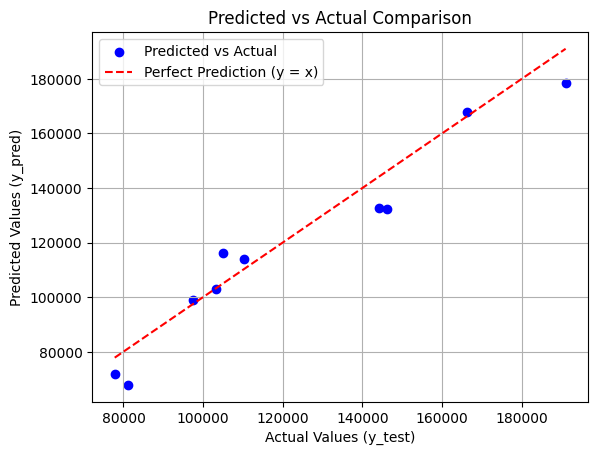

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Actual values (y_test)
y_test = np.array([103282.38, 144259.40, 146121.95, 77798.83, 
                   191050.39, 105008.31, 81229.06, 97483.56, 
                   110352.25, 166187.94])

# Predicted values (y_pred)
y_pred = np.array([103015.20, 132582.28, 132447.74, 71976.10, 
                   178537.48, 116161.24, 67851.69, 98791.73, 
                   113969.44, 167921.07])

# Scatter plot of predicted vs actual
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')

# Plot the ideal line (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         color='red', linestyle='--', label='Perfect Prediction (y = x)')

# Labels and title
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Predicted vs Actual Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
X[:4]

array([[0.0, 0.0, 1.0, 165349.2, 136897.8, 471784.1],
       [1.0, 0.0, 0.0, 162597.7, 151377.59, 443898.53],
       [0.0, 1.0, 0.0, 153441.51, 101145.55, 407934.54],
       [0.0, 0.0, 1.0, 144372.41, 118671.85, 383199.62]], dtype=object)

In [16]:
# Example: Suppose we want to predict for a new company with these values:
# R&D Spend = 160000
# Administration = 130000
# Marketing Spend = 450000
# State = 'California'

# Step 1: Create the raw input (before encoding)
new_data = [[160000, 130000, 450000, 'California']]

# Step 2: Apply the same ColumnTransformer (ct) used during training
# This ensures categorical encoding is consistent
new_data_transformed = ct.transform(new_data)

# Step 3: Predict using the trained regressor
new_prediction = regressor.predict(new_data_transformed)

print("Predicted Output:", new_prediction)


Predicted Output: [187058.43]


In [ ]:
import gradio as gr
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
dataset = pd.read_csv('50_Startups.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Encode categorical variable (State)
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Define prediction function
def predict_profit(rd_spend, admin_spend, marketing_spend, state):
    # Create input row
    input_data = pd.DataFrame([[rd_spend, admin_spend, marketing_spend, state]],
                              columns=["R&D Spend", "Administration", "Marketing Spend", "State"])
    
    # Apply same encoding as training
    input_encoded = ct.transform(input_data)
    
    # Predict profit
    prediction = regressor.predict(input_encoded)[0]
    return f"Predicted Profit: ${prediction:,.2f}"

# Gradio interface
app = gr.Interface(
    fn=predict_profit,
    inputs=[
        gr.Number(label="R&D Spend"),
        gr.Number(label="Administration Spend"),
        gr.Number(label="Marketing Spend"),
        gr.Dropdown(choices=["New York", "California", "Florida"], label="State")
    ],
    outputs="text",
    title="Business Profit Predictor (Multiple Linear Regression)",
    description="Enter company expenses and state to predict the output (e.g., profit)."
)

# Launch app
app.launch()


Running on local URL: http://127.0.0.1:7860/

In [22]:
app.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
* Running on public URL: https://cdba425fa77161e52c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
app.close()

Closing server running on port: 7861


: 